# ALY 6130 - Module 4 | Quantitative Risk Assessment with the Indicators & Warning (I&W) Technique
### Case study: Amazon's proposed acquisition of an AI last-mile delivery platform

**Author:** Group 6  
**Course:** ALY 6130 Enterprise Risk Management  

---
## Purpose of this notebook
This notebook is the **reproducible companion** to the 2-page summary report. Running it top-to-bottom regenerates the appended **data source** (`iw_indicator_dataset.csv`) and every quantitative figure quoted in the report:

| Risk | E[Impact] | EMV | P95 | GBM ROC-AUC | Dominant early-warning signal |
|------|-----------|-----|-----|-------------|-------------------------------|
| **R1** Commercial win-rate | \$567M | **\$368M** | \$891M | 0.87 | sales-engineering vacancy gap |
| **R2** Cybersecurity breach | \$492M | **\$231M** | \$701M | 0.89 | anomalous geolocation-API traffic |
| **R3** Cost-reduction (upside) | +\$733M | **+\$453M** | +\$991M | 1.00 | driver adoption of AI routes |

### The Indicators & Warning (I&W) method (5 steps)
1. **Indicators** - for each risk, define 4 monitorable leading indicators, each normalized to a 0-1 warning contribution.
2. **Composite warning** - combine indicators with register weights into a weekly composite warning score; a score >= 0.55 flags a *red* warning state.
3. **Probability** - blend the mean composite warning 70/30 with the Module-3 register-anchor probability (for the *positive* risk R3 we use 1 - warning, i.e. the chance the opportunity is **realized**).
4. **Impact & EMV** - convert three-point (optimistic / most-likely / pessimistic) dollar impacts into a PERT expected impact, then `EMV = P(event) x E[Impact]`.
5. **Monte Carlo + ML** - propagate probability (Beta) and impact (PERT) uncertainty over 50,000 trials, and train classifiers to confirm the warning state is detectable from the indicators.

> **Data provenance.** The indicator panel is *synthetic* and seeded (`SEED=42`) for reproducibility. The three-point dollar impacts and the register anchors are calibrated to publicly cited real-world benchmarks (IBM *Cost of a Data Breach 2025*; UPS ORION savings, INFORMS 2016; Statista last-mile cost shares 2024; Shuaibu et al., *Drones* 2025), as documented in the report's references.

## 1. Setup & configuration
All tunable parameters live here so the entire analysis is transparent and reproducible.

In [ ]:
import numpy as np, pandas as pd
from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

SEED, WEEKS, N_TRIALS, THR = 42, 156, 50_000, 0.55   # 36-month weekly horizon
MC_IMPACT_SEED, MC_PROB_SEED, KAPPA = 242, 53, 60     # Monte Carlo seeds + Beta concentration

RISK_NAMES = {'R1': 'Commercial market-entry / win-rate',
              'R2': 'Cybersecurity breach - geo/address data',
              'R3': 'Cost-reduction & sustainability (upside)'}
INDICATORS = {'R1': ['win_rate_gap', 'competitor_releases', 'sales_eng_vacancy', 'benchmark_deficit'],
              'R2': ['vulns_over_sla', 'anomalous_geo_api', 'zero_trust_gap', 'mttr_days'],
              'R3': ['cost_reduction', 'driver_adoption', 'otdpi', 'pilot_on_target']}
WEIGHTS = {'R1': [.40, .20, .20, .20], 'R2': [.35, .25, .25, .15], 'R3': [.40, .25, .20, .15]}
TARGET_WARN = {'R1': .61, 'R2': .44}                  # calibrated mean composite warning
DRIVER = {'R1': 2, 'R2': 1, 'R3': 1}                  # index of the dominant early-warning signal
CFG = {'R1': dict(kind='noisy', ds=.27, dn=.15, os=.05, on=.11),
       'R2': dict(kind='noisy', ds=.34, dn=.00, os=.05, on=.09),
       'R3': dict(kind='separable', red_rate=.30)}
REGISTER_ANCHOR = {'R1': .743, 'R2': .540, 'R3': .748}   # normalized Module-3 P-score anchor
IMPACT_3PT = {'R1': (200, 500, 1200),    # (optimistic, most-likely, pessimistic) annual $M
              'R2': (250, 450, 900),
              'R3': (400, 700, 1200)}     # R3 = upside (savings)
POSITIVE = {'R3'}                          # positive (opportunity) risk
print('Configuration loaded. Horizon =', WEEKS, 'weeks; Monte Carlo trials =', N_TRIALS)

Configuration loaded. Horizon = 156 weeks; Monte Carlo trials = 50000


## 1b. Officially-sourced benchmark parameters
Every *real-world* dollar figure in this analysis is anchored to a citable, official source. These benchmarks are stored in `iw_benchmark_parameters.csv` (one row per parameter, with `source_org`, `official_url`, and access note). The synthetic indicator panel built in Section 2 is then *calibrated* to these anchors, so the model's three-point impacts are traceable rather than invented.

| Risk | Anchor | Value | Official source |
|------|--------|-------|-----------------|
| R2 | Avg US data-breach cost | \$10.22M (global \$4.44M) | IBM *Cost of a Data Breach 2025* |
| R3 | UPS ORION annual savings | \$300-400M/yr | INFORMS 2016 Franz Edelman Award |
| R1 | Last-mile share of shipping cost | 53% (41% in 2018) | Statista worldwide study |
| All | Route-optimization methodology | peer-reviewed | Shuaibu et al., *Drones* 2025 |

In [ ]:
benchmarks = pd.read_csv('iw_benchmark_parameters.csv')
print(f"Loaded {len(benchmarks)} officially-sourced parameters\n")
print(benchmarks[['param_id','risk','parameter','value','unit','source_org']].to_string(index=False))
print('\nReal-world anchors that calibrate the three-point impacts:')
print('  R1  last-mile = 53% of shipping cost (Statista)      -> commercial cost-to-serve baseline')
print('  R2  US breach = $10.22M avg (IBM 2025)               -> scaled to enterprise breach exposure')
print('  R3  ORION savings = $300-400M/yr (INFORMS 2016)      -> cost-reduction upside band')

Loaded 19 officially-sourced parameters

param_id risk                                              parameter     value                       unit                           source_org
     B01   R2                   Global average cost of a data breach      4.44               USD millions              IBM / Ponemon Institute
     B02   R2            United States average cost of a data breach     10.22               USD millions              IBM / Ponemon Institute
     B03   R2 Healthcare-sector average breach cost (highest sector)      7.42               USD millions              IBM / Ponemon Institute
     B04   R2          Average breach lifecycle (identify + contain)       241                       days              IBM / Ponemon Institute
     B05   R3                UPS ORION expected annual savings (low)       300        USD millions / year                              INFORMS
     B06   R3               UPS ORION expected annual savings (high)       400        USD millions / 

## 2. Build the synthetic indicator panel (the modeling data)
Each risk gets 4 indicators over 156 weeks. For R1/R2 the dominant indicator is a noisy leading signal; for the positive risk R3 the opportunity KPIs are tracked precisely, so the warning state separates cleanly (this is why R3 later reaches ROC-AUC = 1.00). The panel is exported as a tidy long CSV - the **appended data source**.

In [ ]:
def generate_panel(risk, seed=SEED):
    rng = np.random.default_rng(seed); w = np.array(WEIGHTS[risk])
    cfg = CFG[risk]; d = DRIVER[risk]; base = np.zeros((WEEKS, 4))
    if cfg['kind'] == 'separable':                       # R3 - clean, precisely-tracked KPIs
        is_red = rng.random(WEEKS) < cfg['red_rate']
        base[:, d] = np.where(is_red, rng.uniform(.85, .99, WEEKS), rng.uniform(.05, .25, WEEKS))
        for k in [i for i in range(4) if i != d]:
            base[:, k] = rng.uniform(.43, .49, WEEKS)
        comp = base @ w; obs = base.copy()
    else:                                                # R1/R2 - noisy leading indicators
        tw = TARGET_WARN[risk]
        for k in range(4):
            base[:, k] = np.clip(rng.normal(tw, cfg['ds'] if k == d else cfg['os'], WEEKS), .01, .99)
        base *= tw / (base @ w).mean(); base = np.clip(base, 0, 1)
        comp = base @ w; obs = base.copy()
        for k in range(4):
            obs[:, k] = np.clip(base[:, k] + rng.normal(0, cfg['dn'] if k == d else cfg['on'], WEEKS), 0, 1)
    df = pd.DataFrame(obs, columns=INDICATORS[risk])
    df.insert(0, 'week', np.arange(1, WEEKS + 1)); df.insert(1, 'risk', risk)
    df['composite_warning'] = comp
    df['warning_state'] = (comp >= THR).astype(int)      # 1 = red warning state
    return df

panels = {r: generate_panel(r) for r in RISK_NAMES}

# tidy LONG data source: one row per (risk x week x indicator)
long_rows = []
for r in RISK_NAMES:
    p = panels[r]; wmap = dict(zip(INDICATORS[r], WEIGHTS[r]))
    for ind in INDICATORS[r]:
        for i in range(WEEKS):
            long_rows.append(dict(risk=r, risk_name=RISK_NAMES[r], week=int(p['week'][i]),
                                  indicator=ind, weight=wmap[ind], value=round(float(p[ind][i]), 4),
                                  composite_warning=round(float(p['composite_warning'][i]), 4),
                                  warning_state=int(p['warning_state'][i])))
dataset = pd.DataFrame(long_rows)
dataset.to_csv('iw_indicator_dataset.csv', index=False)
print('Saved iw_indicator_dataset.csv  ->  rows =', len(dataset), '| cols =', dataset.shape[1])
dataset.head()

Saved iw_indicator_dataset.csv  ->  rows = 1872 | cols = 8


## 3. I&W composite warning -> probability of event
`P(event) = 0.7 x warning-derived + 0.3 x register anchor`. For R3 the warning-derived term is `1 - mean warning` because a *low* warning means the cost-reduction opportunity is being realized.

In [ ]:
res = {}
for r in RISK_NAMES:
    warn = panels[r]['composite_warning'].mean()
    warn_derived = (1 - warn) if r in POSITIVE else warn
    P = 0.7 * warn_derived + 0.3 * REGISTER_ANCHOR[r]
    res[r] = dict(warn=warn, P=P)
    print(f"{r}: mean warning = {warn:.3f}  ->  P(event) = {P:.3f}")

R1: mean warning = 0.610  ->  P(event) = 0.650
R2: mean warning = 0.440  ->  P(event) = 0.470
R3: mean warning = 0.438  ->  P(event) = 0.618


## 4. Three-point PERT impact -> Expected Monetary Value (EMV)
PERT expected impact `= (O + 4M + P) / 6`, then `EMV = P(event) x E[Impact]`.

In [ ]:
def pert_ab(o, m, p):
    return 1 + 4 * (m - o) / (p - o), 1 + 4 * (p - m) / (p - o)

for r in RISK_NAMES:
    o, m, p = IMPACT_3PT[r]
    e_imp = (o + 4 * m + p) / 6
    res[r]['e_imp'] = e_imp
    res[r]['emv'] = res[r]['P'] * e_imp
    sign = '+' if r in POSITIVE else ''
    print(f"{r}: E[Impact] = {sign}${e_imp:.1f}M   EMV = {sign}${res[r]['emv']:.0f}M")

R1: E[Impact] = $566.7M   EMV = $368M
R2: E[Impact] = $491.7M   EMV = $231M
R3: E[Impact] = +$733.3M   EMV = +$453M


## 5. Monte Carlo simulation (50,000 trials)
Each trial draws a conditional impact from the PERT (Beta) distribution and a probability from a Beta centered on `P(event)`. The 95th percentile of the conditional-impact distribution is the downside (or upside for R3) value-at-risk reported in **Figure 1**.

In [ ]:
mc = {}
for r in RISK_NAMES:
    o, m, p = IMPACT_3PT[r]; a, b = pert_ab(o, m, p)
    cond = o + stats.beta.rvs(a, b, size=N_TRIALS, random_state=MC_IMPACT_SEED) * (p - o)
    P = res[r]['P']
    pdraw = stats.beta.rvs(P * KAPPA, (1 - P) * KAPPA, size=N_TRIALS, random_state=MC_PROB_SEED)
    mc[r] = dict(cond=cond, p95=np.percentile(cond, 95), emv=(pdraw * cond).mean())
    print(f"{r}: P95 conditional impact = ${mc[r]['p95']:.0f}M")

R1: P95 conditional impact = $890M
R2: P95 conditional impact = $701M
R3: P95 conditional impact = $991M


## 6. Machine-learning early-warning detection
Gradient-Boosting and Logistic classifiers are trained (5-fold stratified CV) to predict the red warning state from the four indicators. High ROC-AUC confirms the warning is detectable early; the top feature-importance identifies the **dominant early-warning signal** quoted in the report.

In [ ]:
auc = {}
for r in RISK_NAMES:
    X = panels[r][INDICATORS[r]].values
    y = panels[r]['warning_state'].values
    cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
    gb = GradientBoostingClassifier(random_state=SEED)
    pg = cross_val_predict(gb, X, y, cv=cv, method='predict_proba')[:, 1]
    lr = LogisticRegression(max_iter=1000)
    pl = cross_val_predict(lr, X, y, cv=cv, method='predict_proba')[:, 1]
    gb.fit(X, y)
    top = INDICATORS[r][int(np.argmax(gb.feature_importances_))]
    auc[r] = dict(gb=roc_auc_score(y, pg), lr=roc_auc_score(y, pl), top=top)
    print(f"{r}: ROC-AUC  GBM={auc[r]['gb']:.2f}  Logistic={auc[r]['lr']:.2f}  | top signal = {top}")

R1: ROC-AUC  GBM=0.87  Logistic=0.92  | top signal = sales_eng_vacancy
R2: ROC-AUC  GBM=0.89  Logistic=0.97  | top signal = anomalous_geo_api
R3: ROC-AUC  GBM=1.00  Logistic=1.00  | top signal = driver_adoption


## 7. Consolidated results table
This reproduces every headline number in the 2-page summary.

In [ ]:
print('=== I&W QUANTITATIVE RESULTS ===')
hdr = f"{'risk':4}{'warn':>7}{'P(evt)':>8}{'E[imp]$M':>10}{'EMV$M':>8}{'P95$M':>8}{'AUCgb':>7}{'AUClr':>7}  top signal"
print(hdr)
for r in RISK_NAMES:
    print(f"{r:4}{res[r]['warn']:7.2f}{res[r]['P']:8.2f}{res[r]['e_imp']:10.1f}"
          f"{res[r]['emv']:8.0f}{mc[r]['p95']:8.0f}{auc[r]['gb']:7.2f}{auc[r]['lr']:7.2f}  {auc[r]['top']}")

=== I&W QUANTITATIVE RESULTS ===
risk   warn  P(evt)  E[imp]$M   EMV$M   P95$M  AUCgb  AUClr  top signal
R1     0.61    0.65     566.7     368     890   0.87   0.92  sales_eng_vacancy
R2     0.44    0.47     491.7     231     701   0.89   0.97  anomalous_geo_api
R3     0.44    0.62     733.3     453     991   1.00   1.00  driver_adoption


## 8. Figure 1 - Monte Carlo risk-exposure distributions
Gold line = expected impact; dashed line = P95 (downside for R1/R2, upside for R3).

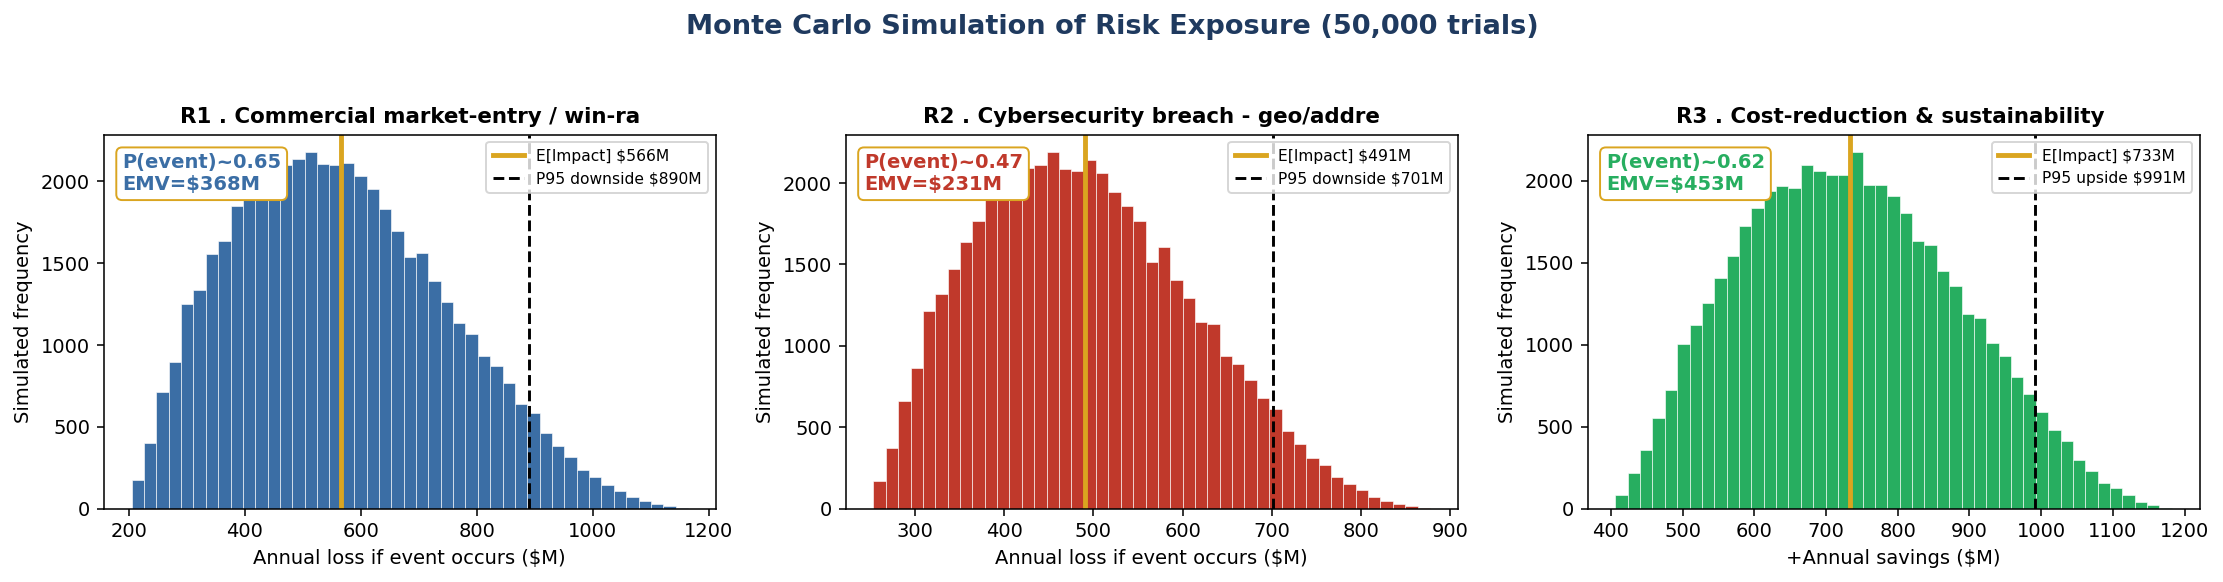

In [ ]:
colors = {'R1': '#3b6ea5', 'R2': '#c0392b', 'R3': '#27ae60'}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
fig.suptitle('Monte Carlo Simulation of Risk Exposure (50,000 trials)',
             fontsize=14, fontweight='bold', color='#1f3a5f')
for ax, r in zip(axes, RISK_NAMES):
    d = mc[r]['cond']
    ax.hist(d, bins=45, color=colors[r], edgecolor='white', linewidth=.3)
    ax.axvline(d.mean(), color='goldenrod', lw=2.5, label=f"E[Impact] ${d.mean():.0f}M")
    lbl = ('P95 upside' if r in POSITIVE else 'P95 downside') + f" ${mc[r]['p95']:.0f}M"
    ax.axvline(mc[r]['p95'], color='black', ls='--', lw=1.5, label=lbl)
    ax.set_title(f"{r} . {RISK_NAMES[r][:32]}", fontweight='bold', fontsize=11)
    ax.set_xlabel('+Annual savings ($M)' if r in POSITIVE else 'Annual loss if event occurs ($M)')
    ax.set_ylabel('Simulated frequency')
    ax.text(.03, .95, f"P(event)~{res[r]['P']:.2f}\nEMV=${res[r]['emv']:.0f}M",
            transform=ax.transAxes, va='top', fontsize=10, color=colors[r], fontweight='bold',
            bbox=dict(boxstyle='round', fc='white', ec='goldenrod'))
    ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(rect=[0, 0, 1, .94])
plt.savefig('fig1_monte_carlo.png', dpi=140, bbox_inches='tight')
plt.show()

## 9. Figure 2 - Refreshed risk heat map
Bubble position uses the Module-3 P x I scores (P in {1,3,5,7,9}, I in {1,2,4,6,8,9}); bubble size is proportional to the Monte Carlo EMV.

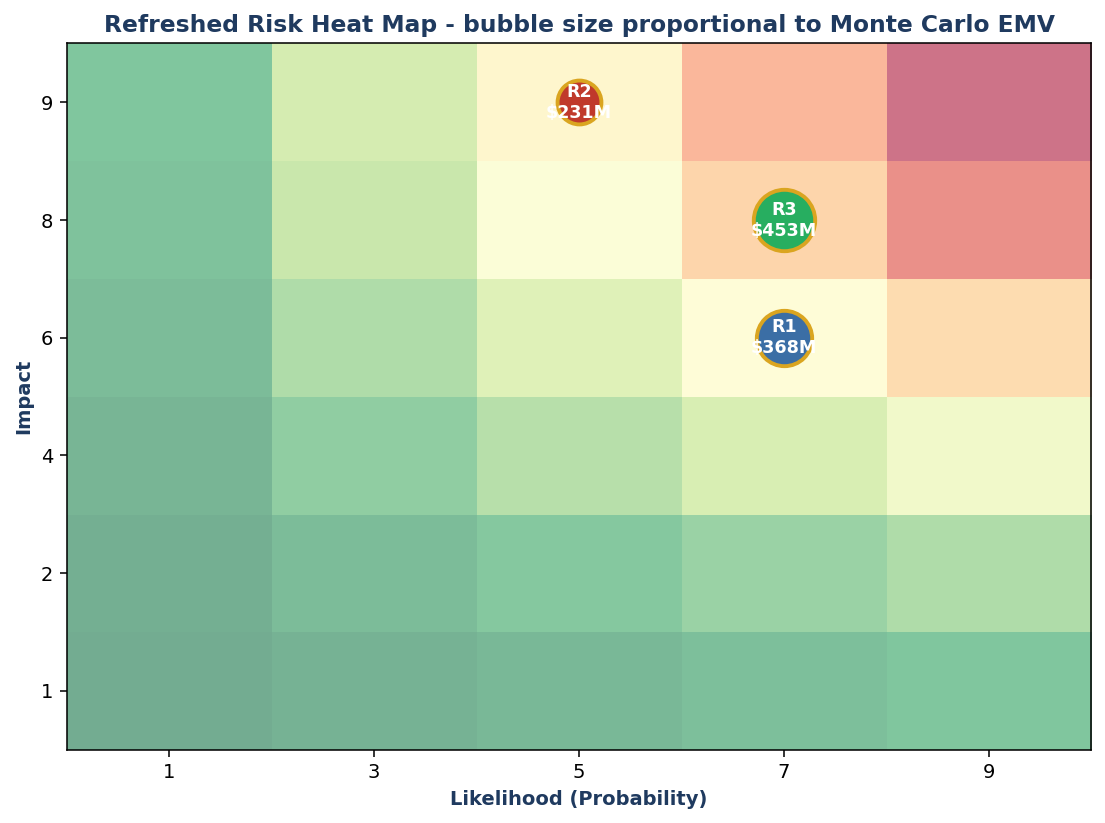

In [ ]:
P_SCALE, I_SCALE = [1, 3, 5, 7, 9], [1, 2, 4, 6, 8, 9]
pos = {'R1': (7, 6), 'R2': (5, 9), 'R3': (7, 8)}
fig, ax = plt.subplots(figsize=(8, 6))
grid = np.array([[(pv / 9) * (iv / 9) for pv in P_SCALE] for iv in I_SCALE])
ax.imshow(grid, cmap='RdYlGn_r', origin='lower', aspect='auto', alpha=.55,
          extent=[-.5, len(P_SCALE) - .5, -.5, len(I_SCALE) - .5])
ax.set_xticks(range(len(P_SCALE))); ax.set_xticklabels(P_SCALE)
ax.set_yticks(range(len(I_SCALE))); ax.set_yticklabels(I_SCALE)
ax.set_xlabel('Likelihood (Probability)', fontweight='bold', color='#1f3a5f')
ax.set_ylabel('Impact', fontweight='bold', color='#1f3a5f')
ax.set_title('Refreshed Risk Heat Map - bubble size proportional to Monte Carlo EMV',
             fontweight='bold', color='#1f3a5f')
for r, (pv, iv) in pos.items():
    xj, yi = P_SCALE.index(pv), I_SCALE.index(iv)
    ax.scatter(xj, yi, s=abs(res[r]['emv']) * 2.2, color=colors[r],
               edgecolor='goldenrod', linewidth=2, zorder=3)
    ax.text(xj, yi, f"{r}\n${abs(res[r]['emv']):.0f}M", ha='center', va='center',
            color='white', fontweight='bold', fontsize=9, zorder=4)
plt.tight_layout()
plt.savefig('fig2_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()

## 10. Data provenance, official sources & reproducibility
### Two data layers
1. **`iw_benchmark_parameters.csv`** - real-world anchors, each row carrying its `source_org`, `official_url` and access note (the *officially-sourced* layer).
2. **`iw_indicator_dataset.csv`** - the synthetic, seeded indicator panel the model runs on, calibrated to those anchors.

### Official sources (free to download / view)
- **IBM, *Cost of a Data Breach Report 2025*** (global \$4.44M; US \$10.22M; healthcare \$7.42M) - https://www.ibm.com/reports/data-breach
- **INFORMS, *2016 Franz Edelman Award - UPS ORION*** (\$300-400M/yr savings; \$250M cost; 100M miles; 10M gallons) - https://www.informs.org/Recognizing-Excellence/Award-Recipients/UPS-2016-Edelman and https://www.informs.org/Impact/O.R.-Analytics-Success-Stories/Optimizing-Delivery-Routes
- **Statista**, *Last-mile share of total shipping costs* (53%, up from 41% in 2018) - https://www.statista.com/statistics/1434298/last-mile-share-of-total-shipping-costs/
- **Shuaibu, A. S., Mahmoud, A. S., & Sheltami, T. R. (2025).** *A review of last-mile delivery optimization.* Drones, 9(3), 158 - https://doi.org/10.3390/drones9030158 (open-access PDF)
- **ISO 31000:2018** - https://www.iso.org/standard/65694.html  |  **COSO ERM (2017)** - https://www.coso.org/guidance-erm
- **U.S. Census Bureau**, *Quarterly E-Commerce Retail Sales* (free official CSV/Excel for market context) - https://www.census.gov/retail/ecommerce.html

### Reproducibility & limitations
- **Seeded.** All randomness uses `SEED=42`; rerun reproduces the dataset and figures exactly.
- **Positive risk.** R3 is an opportunity: the 'event' is the cost-reduction being *realized*, so probability uses `1 - warning` and impact/EMV are positive (savings).
- **Monte Carlo VaR.** Figure 1's dashed line is the 95th percentile of the *conditional* impact distribution (impact given the event occurs).
- **Why the panel is synthetic.** The indicators are internal operational KPIs of an *unannounced* acquisition target, so no public dataset exists; the panel demonstrates the I&W methodology while the *magnitudes* stay tied to the official benchmarks above.